# Banking Customer Churn Analysis

## Project Overview

This project analyzes customer churn in a banking context using Python.

The goal is to understand which customer characteristics are associated with churn and to identify patterns that can support customer retention strategies.

The analysis focuses on data cleaning, exploratory data analysis, churn rate calculation, customer segmentation, and business interpretation.

## Dataset

The dataset contains customer-level banking information, including demographics, credit score, geography, account balance, product usage, activity status, estimated salary, and churn status.

The target variable is:

`Exited`

Where:

`0` = customer stayed  
`1` = customer churned

## Tools Used

- Python
- pandas
- NumPy
- matplotlib
- Jupyter Notebook

In [5]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the Dataset

In [6]:
# Load the dataset

df = pd.read_csv("../data/churn.csv")

# Preview the first rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0
2,3,15619304,Onio,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0


## 2. Initial Data Overview

In [7]:
# Check dataset dimensions

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 10000
Columns: 14


In [8]:
# Check column names and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
# Summary statistics for numerical columns

df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"5,000.50","15,690,940.57",650.53,38.92,5.01,"76,485.89",1.53,0.71,0.52,"100,090.24",0.20
std,"2,886.90","71,936.19",96.65,10.49,2.89,"62,397.41",0.58,0.46,0.50,"57,510.49",0.40
min,1.00,"15,565,701.00",350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,"2,500.75","15,628,528.25",584.00,32.00,3.00,0.00,1.00,0.00,0.00,"51,002.11",0.00
50%,"5,000.50","15,690,738.00",652.00,37.00,5.00,"97,198.54",1.00,1.00,1.00,"100,193.91",0.00
75%,"7,500.25","15,753,233.75",718.00,44.00,7.00,"127,644.24",2.00,1.00,1.00,"149,388.25",0.00
max,"10,000.00","15,815,690.00",850.00,92.00,10.00,"250,898.09",4.00,1.00,1.00,"199,992.48",1.00


## 3. Data Cleaning and Column Check

In this section, we check column names, missing values, duplicate rows, and remove columns that are not useful for churn analysis.

In [10]:
# Check column names

df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
# Check missing values

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [13]:
# Drop columns that are not useful for churn analysis

df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1
1,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0
2,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1
3,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0
4,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0


In [14]:
# Check cleaned dataset shape

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")

Original dataset shape: (10000, 14)
Cleaned dataset shape: (10000, 11)


## 4. Target Variable Analysis

The target variable is `Exited`.

`0` means the customer stayed with the bank.  
`1` means the customer churned.

This section calculates the overall churn rate and checks whether the dataset is balanced or imbalanced.

In [15]:
# Count customers by churn status

churn_counts = df_clean["Exited"].value_counts()

churn_counts

Exited
0    7963
1    2037
Name: count, dtype: int64

In [16]:
# Churn percentage

churn_rate = df_clean["Exited"].value_counts(normalize=True) * 100

churn_rate.round(2)

Exited
0   79.63
1   20.37
Name: proportion, dtype: float64

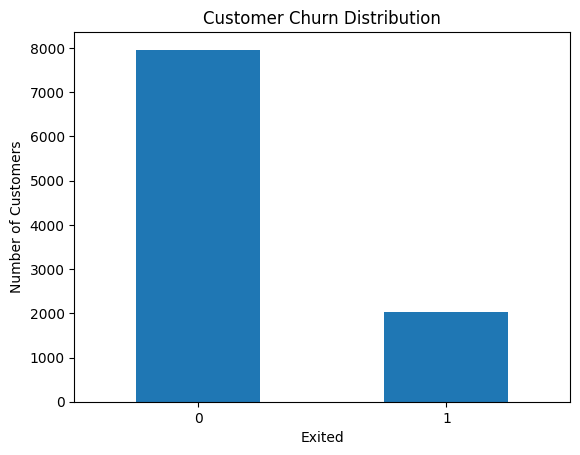

In [63]:
# Visualize churn distribution

churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.savefig("../images/churn_distribution.png", bbox_inches="tight")
plt.show()

### Initial Interpretation

The dataset contains **10,000 customers**.

Out of all customers:

- **7,963 customers** stayed with the bank.
- **2,037 customers** churned.

The overall churn rate is **20.37%**, while **79.63%** of customers stayed.

This means that approximately **1 out of 5 customers left the bank**.

The dataset is moderately imbalanced because the churned class is much smaller than the non-churned class. This is common in churn prediction problems and should be considered later if a machine learning model is built.

## 5. Categorical Feature Analysis

This section analyzes churn patterns across categorical variables such as geography, gender, credit card ownership, and active membership.

The goal is to identify whether certain customer groups have higher churn rates.

In [18]:
# Churn rate by geography

geo_churn = df_clean.groupby("Geography")["Exited"].agg(["count", "sum", "mean"]).reset_index()

geo_churn.columns = ["Geography", "Total Customers", "Churned Customers", "Churn Rate"]

geo_churn["Churn Rate"] = (geo_churn["Churn Rate"] * 100).round(2)

geo_churn.sort_values("Churn Rate", ascending=False)

,Geography,Total Customers,Churned Customers,Churn Rate
1,Germany,2509,814,32.44
2,Spain,2477,413,16.67
0,France,5014,810,16.15


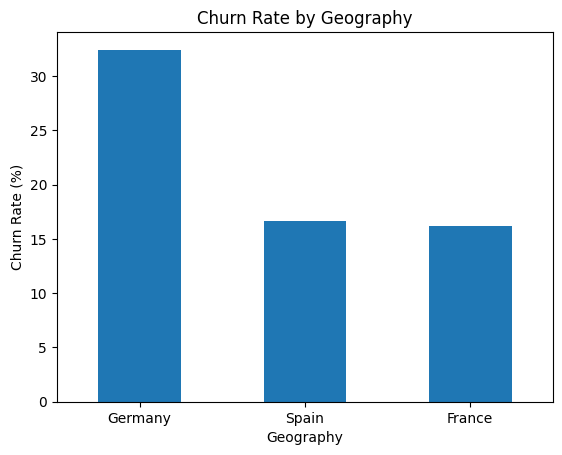

In [64]:
# Visualize churn rate by geography

geo_churn.sort_values("Churn Rate", ascending=False).plot(
    x="Geography",
    y="Churn Rate",
    kind="bar",
    legend=False
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.savefig("../images/churn_by_geography.png", bbox_inches="tight")
plt.show()

In [20]:
# Churn rate by gender

gender_churn = df_clean.groupby("Gender")["Exited"].agg(["count", "sum", "mean"]).reset_index()

gender_churn.columns = ["Gender", "Total Customers", "Churned Customers", "Churn Rate"]

gender_churn["Churn Rate"] = (gender_churn["Churn Rate"] * 100).round(2)

gender_churn.sort_values("Churn Rate", ascending=False)

,Gender,Total Customers,Churned Customers,Churn Rate
0,Female,4543,1139,25.07
1,Male,5457,898,16.46


In [21]:
# Churn rate by active membership

active_churn = df_clean.groupby("IsActiveMember")["Exited"].agg(["count", "sum", "mean"]).reset_index()

active_churn.columns = ["Is Active Member", "Total Customers", "Churned Customers", "Churn Rate"]

active_churn["Churn Rate"] = (active_churn["Churn Rate"] * 100).round(2)

active_churn.sort_values("Churn Rate", ascending=False)

,Is Active Member,Total Customers,Churned Customers,Churn Rate
0,0,4849,1302,26.85
1,1,5151,735,14.27


In [22]:
# Churn rate by credit card ownership

card_churn = df_clean.groupby("HasCrCard")["Exited"].agg(["count", "sum", "mean"]).reset_index()

card_churn.columns = ["Has Credit Card", "Total Customers", "Churned Customers", "Churn Rate"]

card_churn["Churn Rate"] = (card_churn["Churn Rate"] * 100).round(2)

card_churn.sort_values("Churn Rate", ascending=False)

,Has Credit Card,Total Customers,Churned Customers,Churn Rate
0,0,2945,613,20.81
1,1,7055,1424,20.18


## 6. Numerical Feature Analysis

This section analyzes numerical variables such as age, credit score, balance, tenure, number of products, and estimated salary.

The goal is to compare customers who stayed with customers who churned and identify numerical patterns related to churn.

In [23]:
# Compare average numerical values by churn status

numeric_summary = df_clean.groupby("Exited")[
    ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
].mean().round(2)

numeric_summary

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Exited,,,,,,
0,651.85,37.41,5.03,"72,745.30",1.54,"99,738.39"
1,645.35,44.84,4.93,"91,108.54",1.48,"101,465.68"


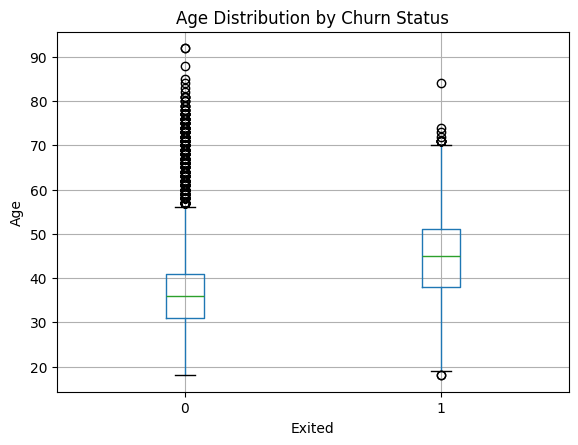

In [24]:
# Age distribution by churn status

df_clean.boxplot(column="Age", by="Exited")

plt.title("Age Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Exited")
plt.ylabel("Age")
plt.show()

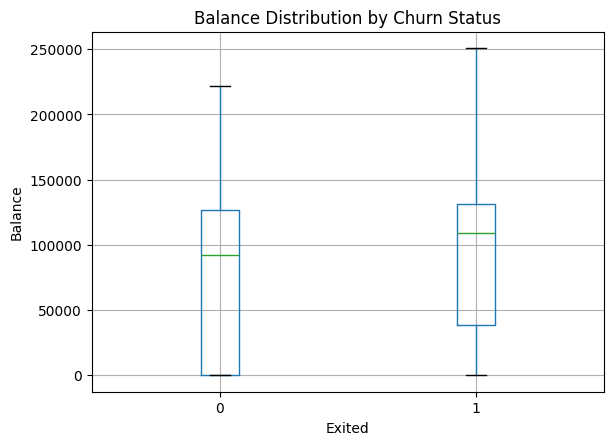

In [25]:
# Balance distribution by churn status

df_clean.boxplot(column="Balance", by="Exited")

plt.title("Balance Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

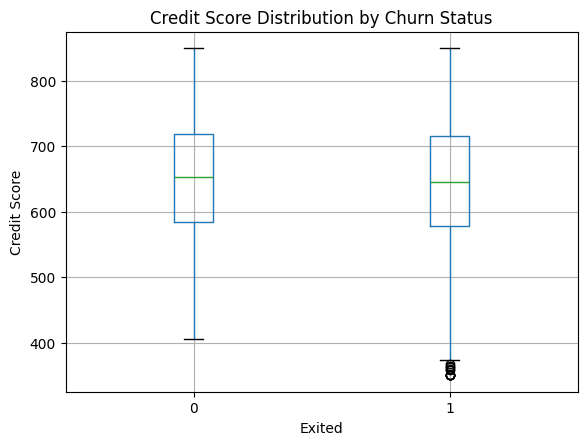

In [26]:
# Credit score distribution by churn status

df_clean.boxplot(column="CreditScore", by="Exited")

plt.title("Credit Score Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Exited")
plt.ylabel("Credit Score")
plt.show()

In [27]:
# Churn rate by number of products

products_churn = df_clean.groupby("NumOfProducts")["Exited"].agg(["count", "sum", "mean"]).reset_index()

products_churn.columns = ["Number of Products", "Total Customers", "Churned Customers", "Churn Rate"]

products_churn["Churn Rate"] = (products_churn["Churn Rate"] * 100).round(2)

products_churn.sort_values("Number of Products")

,Number of Products,Total Customers,Churned Customers,Churn Rate
0,1,5084,1409,27.71
1,2,4590,348,7.58
2,3,266,220,82.71
3,4,60,60,100.00


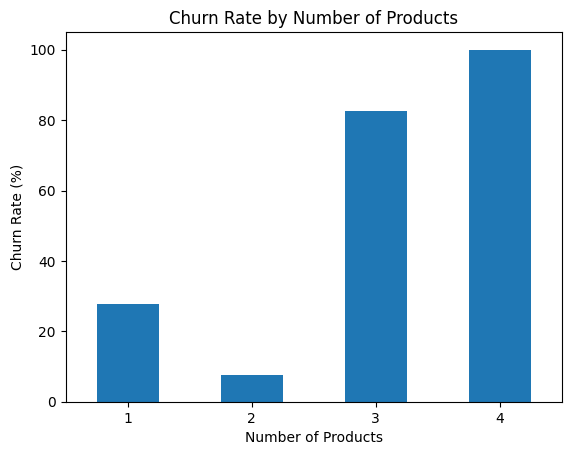

In [28]:
# Visualize churn rate by number of products

products_churn.plot(
    x="Number of Products",
    y="Churn Rate",
    kind="bar",
    legend=False
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 7. Customer Segmentation

This section creates simple customer segments based on age, balance, and activity status.

The goal is to make the churn analysis more business-oriented and easier to interpret for retention strategy.

In [29]:
# Create age groups

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["Under 30", "30-39", "40-49", "50-59", "60+"]
)

age_group_churn = df_clean.groupby("AgeGroup", observed=True)["Exited"].agg(["count", "sum", "mean"]).reset_index()

age_group_churn.columns = ["Age Group", "Total Customers", "Churned Customers", "Churn Rate"]

age_group_churn["Churn Rate"] = (age_group_churn["Churn Rate"] * 100).round(2)

age_group_churn

,Age Group,Total Customers,Churned Customers,Churn Rate
0,Under 30,1968,148,7.52
1,30-39,4451,538,12.09
2,40-49,2320,788,33.97
3,50-59,797,448,56.21
4,60+,464,115,24.78


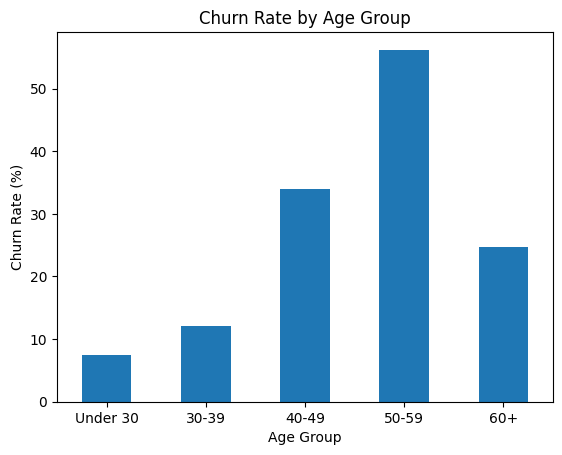

In [30]:
# Visualize churn rate by age group

age_group_churn.plot(
    x="Age Group",
    y="Churn Rate",
    kind="bar",
    legend=False
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [31]:
# Create balance groups

df_clean["BalanceGroup"] = pd.cut(
    df_clean["Balance"],
    bins=[-1, 0, 50000, 100000, 150000, df_clean["Balance"].max()],
    labels=["Zero Balance", "Low Balance", "Medium Balance", "High Balance", "Very High Balance"]
)

balance_group_churn = df_clean.groupby("BalanceGroup", observed=True)["Exited"].agg(["count", "sum", "mean"]).reset_index()

balance_group_churn.columns = ["Balance Group", "Total Customers", "Churned Customers", "Churn Rate"]

balance_group_churn["Churn Rate"] = (balance_group_churn["Churn Rate"] * 100).round(2)

balance_group_churn

,Balance Group,Total Customers,Churned Customers,Churn Rate
0,Zero Balance,3617,500,13.82
1,Low Balance,75,26,34.67
2,Medium Balance,1509,300,19.88
3,High Balance,3830,987,25.77
4,Very High Balance,969,224,23.12


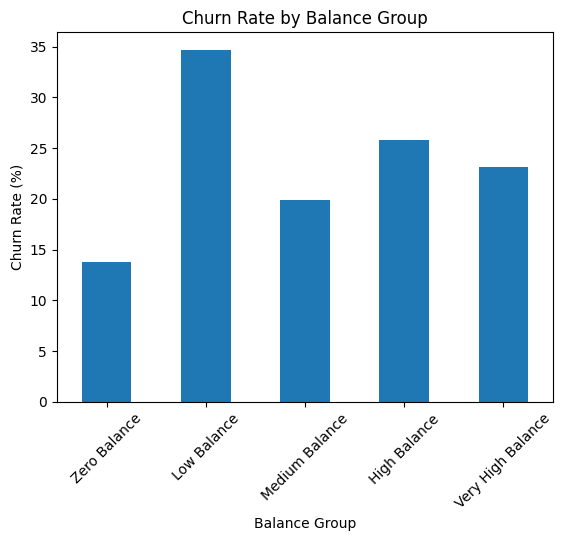

In [32]:
# Visualize churn rate by balance group

balance_group_churn.plot(
    x="Balance Group",
    y="Churn Rate",
    kind="bar",
    legend=False
)

plt.title("Churn Rate by Balance Group")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [33]:
# Churn rate by age group and activity status

age_activity_churn = df_clean.groupby(
    ["AgeGroup", "IsActiveMember"],
    observed=True
)["Exited"].agg(["count", "sum", "mean"]).reset_index()

age_activity_churn.columns = ["Age Group", "Is Active Member", "Total Customers", "Churned Customers", "Churn Rate"]

age_activity_churn["Churn Rate"] = (age_activity_churn["Churn Rate"] * 100).round(2)

age_activity_churn.sort_values("Churn Rate", ascending=False)

,Age Group,Is Active Member,Total Customers,Churned Customers,Churn Rate
6,50-59,0,336,288,85.71
8,60+,0,89,73,82.02
4,40-49,0,1226,510,41.60
7,50-59,1,461,160,34.71
5,40-49,1,1094,278,25.41
2,30-39,0,2236,334,14.94
9,60+,1,375,42,11.20
0,Under 30,0,962,97,10.08
3,30-39,1,2215,204,9.21
1,Under 30,1,1006,51,5.07


## 8. Correlation and Feature Relationships

This section checks relationships between numerical variables and churn.

The goal is to identify which numerical features may be more strongly associated with customer churn.

In [34]:
# Correlation matrix for numerical features

correlation_matrix = df_clean[
    ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary", "Exited"]
].corr()

correlation_matrix.round(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.00,-0.03
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01,0.28
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.01,-0.01
Balance,0.01,0.03,-0.01,1.00,-0.30,0.01,0.12
NumOfProducts,0.01,-0.03,0.01,-0.30,1.00,0.01,-0.05
EstimatedSalary,-0.00,-0.01,0.01,0.01,0.01,1.00,0.01
Exited,-0.03,0.28,-0.01,0.12,-0.05,0.01,1.00


In [35]:
# Correlation with the target variable

target_correlation = correlation_matrix["Exited"].sort_values(ascending=False)

target_correlation.round(3)

Exited             1.00
Age                0.28
Balance            0.12
EstimatedSalary    0.01
Tenure            -0.01
CreditScore       -0.03
NumOfProducts     -0.05
Name: Exited, dtype: float64

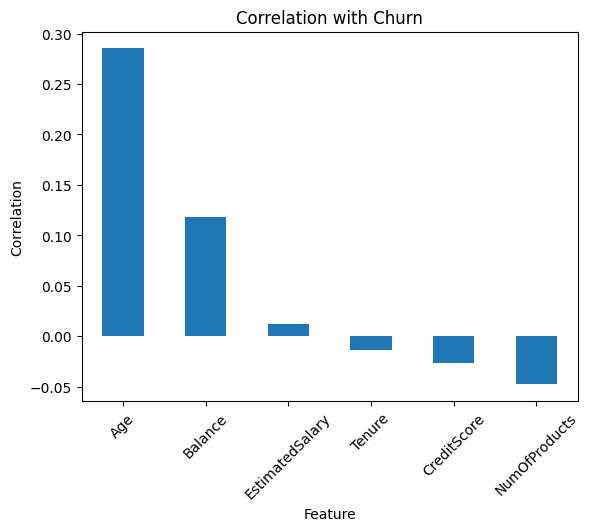

In [36]:
# Visualize correlation with churn

target_correlation.drop("Exited").plot(kind="bar")

plt.title("Correlation with Churn")
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

### Interpretation

The correlation analysis shows that **Age** has the strongest positive relationship with churn among the numerical variables.

Main findings:

- **Age** has the highest positive correlation with churn: **0.28**.
- **Balance** also has a positive correlation with churn: **0.12**.
- **EstimatedSalary** has almost no relationship with churn: **0.01**.
- **Tenure** has a very weak negative correlation with churn: **-0.01**.
- **CreditScore** has a weak negative correlation with churn: **-0.03**.
- **NumOfProducts** has a weak negative correlation with churn: **-0.05**.

This suggests that older customers and customers with higher account balances may be more likely to churn in this dataset.

However, correlation does not prove causation. These results only show linear relationships and should be combined with categorical analysis, segmentation, and later machine learning models.

1. Project Overview
2. Load Dataset
3. Data Cleaning
4. Target Variable Analysis
5. Categorical Feature Analysis
6. Numerical Feature Analysis
7. Customer Segmentation
8. Correlation Analysis

## 9. Basic Machine Learning Model

This section builds a simple baseline machine learning model to predict customer churn.

The goal is not to create the perfect model, but to demonstrate a complete basic workflow:

- feature selection
- encoding categorical variables
- train/test split
- model training
- model evaluation

In [38]:
# Import machine learning libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [39]:
# Define features and target

X = df_clean.drop(columns=["Exited", "AgeGroup", "BalanceGroup"])
y = df_clean["Exited"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (10000, 10)
Target vector shape: (10000,)


In [40]:
# Identify categorical and numerical columns

categorical_features = ["Geography", "Gender"]
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Geography', 'Gender']
Numerical features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [41]:
# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (8000, 10)
Test set: (2000, 10)


In [44]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create preprocessing and model pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000))
    ]
)

In [45]:
# Train the model

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [46]:
# Make predictions on the test set

y_pred = model.predict(X_test)

In [47]:
# Evaluate model performance

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.81
Precision: 0.59
Recall: 0.19
F1 Score: 0.28


In [48]:
# Confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)

conf_matrix

array([[1540,   53],
       [ 331,   76]])

In [49]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



## 10. Random Forest Model

The logistic regression model achieved good overall accuracy, but it had low recall for churned customers.

This means the model missed many customers who actually left the bank.

In this section, we train a Random Forest model to compare performance with the baseline logistic regression model.

In [52]:
# Import Random Forest model

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Train Random Forest model

rf_model.fit(X_train, y_train)

# Make predictions with Random Forest

rf_pred = rf_model.predict(X_test)

In [53]:
# Evaluate Random Forest model

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2f}")
print(f"Random Forest Precision: {rf_precision:.2f}")
print(f"Random Forest Recall: {rf_recall:.2f}")
print(f"Random Forest F1 Score: {rf_f1:.2f}")

Random Forest Accuracy: 0.86
Random Forest Precision: 0.76
Random Forest Recall: 0.45
Random Forest F1 Score: 0.57


In [54]:
# Random Forest confusion matrix

rf_conf_matrix = confusion_matrix(y_test, rf_pred)

rf_conf_matrix

# Random Forest classification report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000



## 11. Gradient Boosting Model

To improve model comparison, this section trains a Gradient Boosting model.

Gradient Boosting is usually stronger than a simple logistic regression because it can capture non-linear relationships between customer features and churn.

The goal is to compare three models:

- Logistic Regression
- Random Forest
- Gradient Boosting

In [55]:
# Import Gradient Boosting model

from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting pipeline

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train Gradient Boosting model

gb_model.fit(X_train, y_train)

# Make predictions with Gradient Boosting

gb_pred = gb_model.predict(X_test)

In [56]:
# Evaluate Gradient Boosting model

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.2f}")
print(f"Gradient Boosting Precision: {gb_precision:.2f}")
print(f"Gradient Boosting Recall: {gb_recall:.2f}")
print(f"Gradient Boosting F1 Score: {gb_f1:.2f}")

Gradient Boosting Accuracy: 0.87
Gradient Boosting Precision: 0.80
Gradient Boosting Recall: 0.50
Gradient Boosting F1 Score: 0.61


In [57]:
# Gradient Boosting classification report

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000



In [60]:
# Compare all models

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [accuracy, rf_accuracy, gb_accuracy],
    "Precision": [precision, rf_precision, gb_precision],
    "Recall": [recall, rf_recall, gb_recall],
    "F1 Score": [f1, rf_f1, gb_f1]
})

model_comparison.round(2)



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.81,0.59,0.19,0.28
1,Random Forest,0.86,0.76,0.45,0.57
2,Gradient Boosting,0.87,0.80,0.50,0.61


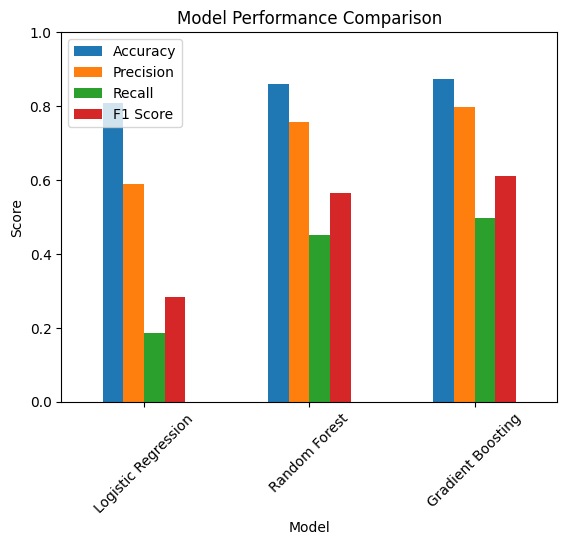

In [65]:
# Visualize model comparison

model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar")

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.savefig("../images/model_comparison.png", bbox_inches="tight")
plt.show()

### Model Comparison Interpretation

Three machine learning models were compared: Logistic Regression, Random Forest, and Gradient Boosting.

The Gradient Boosting model achieved the best overall performance:

- Accuracy: **0.87**
- Precision: **0.80**
- Recall: **0.50**
- F1 Score: **0.61**

Compared with Logistic Regression, Gradient Boosting significantly improved the ability to detect churned customers. Recall increased from **0.19** to **0.50**, and F1 Score increased from **0.28** to **0.61**.

Random Forest also performed better than Logistic Regression, but Gradient Boosting achieved the best balance between precision and recall.

The most important metric for this business problem is recall, because the bank wants to identify customers who are at risk of leaving. A higher recall means the bank can detect more potential churners and target them with retention actions.

Overall, Gradient Boosting is the best-performing model in this project. However, recall is still not perfect, so future improvements could include threshold tuning, hyperparameter optimization, additional feature engineering, or using more advanced models.

### Model Comparison Interpretation

## 12. Business Recommendations

Based on the exploratory data analysis and machine learning results, several business recommendations can be suggested for customer retention.

### 1. Focus on older customers

Age showed the strongest positive relationship with churn among numerical variables.

Older customers had a higher tendency to leave the bank compared with younger customers.

The bank should monitor older customer segments more carefully and offer personalized retention campaigns, such as dedicated support, loyalty benefits, or financial advisory services.

### 2. Monitor customers with higher account balances

Balance had a positive relationship with churn.

This means that some customers with higher balances may still be at risk of leaving the bank.

These customers are important because losing them can have a stronger financial impact. The bank should identify high-balance customers with churn risk and provide premium retention offers.

### 3. Improve engagement of inactive customers

Customer activity is an important churn-related factor.

Inactive customers are usually more likely to churn because they have weaker engagement with the bank.

The bank can reduce churn risk by encouraging inactive customers to use more services, digital banking tools, cards, or personalized offers.

### 4. Use churn prediction for targeted retention

The Gradient Boosting model performed best among the tested models.

It can be used as a starting point for identifying customers who are more likely to churn.

Instead of applying the same campaign to all customers, the bank can focus retention actions on customers with higher predicted churn risk.

### 5. Improve the model before real business use

Although Gradient Boosting was the best model in this project, recall was still not perfect.

Before using the model in a real banking environment, the bank should improve it with threshold tuning, hyperparameter optimization, additional features, and more detailed transaction-level customer behavior data.

## 13. Final Conclusion

This project analyzed customer churn in a banking context using Python.

The analysis included data cleaning, exploratory data analysis, customer segmentation, correlation analysis, and machine learning modeling.

The dataset contained 10,000 customers, with an overall churn rate of 20.37%.

The analysis showed that age, balance, geography, activity status, and number of products are important factors related to churn behavior.

Three machine learning models were tested:

- Logistic Regression
- Random Forest
- Gradient Boosting

Gradient Boosting achieved the best overall performance, with 0.87 accuracy, 0.80 precision, 0.50 recall, and 0.61 F1 score.

The project demonstrates how data analysis and machine learning can support customer retention strategy in retail banking.